# Import libraries

In [1]:
# Видаляємо потенційно конфліктні пакети
!pip uninstall -y transformers datasets accelerate evaluate torch torchvision torchaudio

# Встановлюємо сумісні версії
!pip install -q \
torch==2.7.1 \
torchvision==0.22.1 \
torchaudio==2.7.1 \
transformers==4.52.4 \
datasets==3.6.0 \
accelerate==1.7.0 \
evaluate==0.4.3 \
safetensors==0.5.3 \
sentencepiece==0.2.0

Found existing installation: transformers 5.13.1
Uninstalling transformers-5.13.1:
  Successfully uninstalled transformers-5.13.1
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0
Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 66.4 

In [2]:
import torch
import torchvision
import torchaudio
import transformers
import datasets
import accelerate

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("torchaudio:", torchaudio.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("accelerate:", accelerate.__version__)

torch: 2.7.1+cu126
torchvision: 0.22.1+cu126
torchaudio: 2.7.1+cu126
transformers: 4.52.4
datasets: 3.6.0
accelerate: 1.7.0


In [ ]:
import json
import time

import joblib
import numpy as np
import pandas as pd
import torch
import accelerate

from datasets import Dataset
from scipy.special import softmax
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from pathlib import Path
from model_utils import classify_analysis_bert, error_analysis_bert

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
RANDOM_STATE = 42

PROCESS_DATA_PATH = "/content/drive/MyDrive/ML_course/Final_Project/preprocess_data"
MODEL_PATH = "/content/drive/MyDrive/ML_course/Final_Project/models/distilbert_baseline"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

Using device: cuda


# Data Loading

In [7]:
train_df = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_bert.parquet")
val_df = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_bert.parquet")

In [8]:
with open(f"{PROCESS_DATA_PATH}/bert_config.json", "r",) as f:
    config = json.load(f)

MODEL_CHECKPOINT = config["model_checkpoint"]
MAX_LENGTH = config["max_length"]

print(config)

{'model_checkpoint': 'distilbert-base-uncased', 'max_length': 80}


# Tokenizer

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Create Datasets

In [ ]:
def tokenize_function(examples):

    return tokenizer(
        examples["question1_clean"],
        examples["question2_clean"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

In [10]:
train_dataset = Dataset.from_pandas(train_df[["question1_clean", "question2_clean", "is_duplicate"]])
val_dataset = Dataset.from_pandas(val_df[["question1_clean", "question2_clean", "is_duplicate"]])

In [11]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/261296 [00:00<?, ? examples/s]

Map:   0%|          | 0/62133 [00:00<?, ? examples/s]

In [12]:
train_dataset = train_dataset.rename_column("is_duplicate", "labels")
val_dataset = val_dataset.rename_column("is_duplicate", "labels")

In [13]:
train_dataset = train_dataset.remove_columns(["question1_clean", "question2_clean"])
val_dataset = val_dataset.remove_columns(["question1_clean", "question2_clean"])

In [14]:
train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")

In [15]:
print(train_dataset)
print(train_dataset[0])

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 261296
})
{'labels': tensor(0), 'input_ids': tensor([ 101, 2054, 2003, 6742, 2968, 1998, 2054, 2003, 6143, 2968, 1029,  102,
        2054, 2024, 1996, 6742, 5919, 1997, 6143, 2968, 1029,  102,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])}


# Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
)

model.to(DEVICE)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/ML_course/Final_Project/bert_results",  # Зберігати одразу на Google Drive

    do_train=True,
    do_eval=True,

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    weight_decay=0.01,

    optim="adamw_torch",

    # Оцінка та збереження кожні 500 кроків
    eval_strategy="steps",
    eval_steps=500,

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,  # залишати лише 2 останні чекпоїнти

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=100,

    report_to="none",

    seed=RANDOM_STATE,
    fp16=torch.cuda.is_available()
)

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
start_time = time.perf_counter()
trainer.train()
training_time = time.perf_counter() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

Step,Training Loss,Validation Loss,Log Loss,F1,Runtime,Samples Per Second,Steps Per Second
500,0.429500,0.443825,0.443826,0.721703,44.781400,1387.474000,86.732000
1000,0.420700,0.422348,0.422350,0.723525,45.978100,1351.362000,84.475000
1500,0.386600,0.408314,0.408314,0.735875,51.353000,1209.920000,75.633000
2000,0.355300,0.470613,0.470616,0.696460,45.387100,1368.959000,85.575000
2500,0.355600,0.410431,0.410432,0.755899,46.182700,1345.373000,84.101000
3000,0.353100,0.397848,0.397848,0.746820,46.105000,1347.641000,84.242000
3500,0.351800,0.406964,0.406964,0.753628,45.646100,1361.189000,85.089000
4000,0.361400,0.385137,0.385137,0.761858,46.361500,1340.185000,83.776000
4500,0.356300,0.398613,0.398613,0.755051,45.848700,1355.174000,84.713000
5000,0.326900,0.411023,0.411023,0.736167,45.651700,1361.024000,85.079000


In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/ML_course/Final project/bert_results/checkpoint-25000"

start_time = time.perf_counter()

trainer.train(resume_from_checkpoint=CHECKPOINT_PATH)

training_time = time.perf_counter() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

	save_steps: 500 (from args) != 1000 (from trainer_state.json)


Step,Training Loss,Validation Loss,Log Loss,F1,Runtime,Samples Per Second,Steps Per Second
25500,0.208100,0.503918,0.503908,0.749450,44.545400,1394.823000,87.192000
26000,0.191800,0.512780,0.512771,0.765327,49.381200,1258.233000,78.653000
26500,0.174200,0.523726,0.523723,0.773258,46.212200,1344.516000,84.047000
27000,0.173900,0.562089,0.562082,0.761127,45.956100,1352.007000,84.515000
27500,0.189900,0.529021,0.529015,0.770231,45.553200,1363.967000,85.263000
28000,0.173200,0.571283,0.571273,0.758202,45.439900,1367.367000,85.476000
28500,0.173900,0.534422,0.534411,0.772845,45.706600,1359.389000,84.977000
29000,0.197900,0.538711,0.538706,0.761064,46.182200,1345.388000,84.102000
29500,0.166300,0.518999,0.518992,0.772216,46.461100,1337.313000,83.597000
30000,0.166800,0.546731,0.546720,0.783259,45.957400,1351.969000,84.513000


In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/ML_course/Final_Project/bert_results/checkpoint-48000"

start_time = time.perf_counter()

trainer.train(resume_from_checkpoint=CHECKPOINT_PATH)

training_time = time.perf_counter() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

	save_steps: 500 (from args) != 1000 (from trainer_state.json)


Step,Training Loss,Validation Loss,Log Loss,F1,Runtime,Samples Per Second,Steps Per Second
48500,0.099800,0.561949,0.561935,0.778544,48.228500,1288.305000,80.533000


Could not locate the best model at /content/drive/MyDrive/ML_course/Final project/bert_results/checkpoint-14000/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.



Training time: 140.49 seconds


In [ ]:
trainer.evaluate()

{'eval_loss': 0.5703635215759277,
 'eval_log_loss': 0.5703511697828335,
 'eval_f1': 0.7786023500309215,
 'eval_runtime': 46.8356,
 'eval_samples_per_second': 1326.62,
 'eval_steps_per_second': 82.928,
 'epoch': 3.0}

In [ ]:
Path(MODEL_PATH).mkdir(parents=True, exist_ok=True)

trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: /content/drive/MyDrive/ML_course/Final_Project/models/distilbert_baseline


# Evaluation

In [17]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

In [19]:
trainer = Trainer(model=model)

Training
Log Loss      : 0.1078
ROC-AUC       : 0.9923
F1-score      : 0.9556
Inference time: 669.4805 s


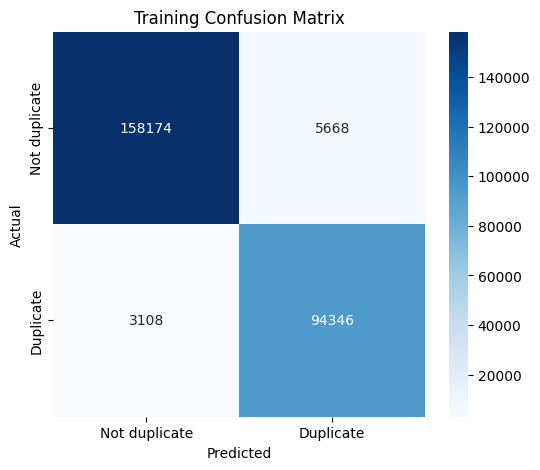


Classification Report:

              precision    recall  f1-score   support

           0     0.9807    0.9654    0.9730    163842
           1     0.9433    0.9681    0.9556     97454

    accuracy                         0.9664    261296
   macro avg     0.9620    0.9668    0.9643    261296
weighted avg     0.9668    0.9664    0.9665    261296



In [35]:
train_bert_results = classify_analysis_bert(trainer, train_dataset, 'Training')

Validation
Log Loss      : 0.5704
ROC-AUC       : 0.9223
F1-score      : 0.7787
Inference time: 156.8448 s


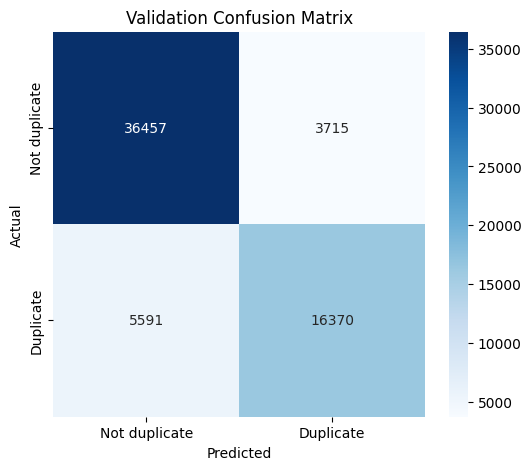


Classification Report:

              precision    recall  f1-score   support

           0     0.8670    0.9075    0.8868     40172
           1     0.8150    0.7454    0.7787     21961

    accuracy                         0.8502     62133
   macro avg     0.8410    0.8265    0.8327     62133
weighted avg     0.8487    0.8502    0.8486     62133



In [37]:
val_bert_results = classify_analysis_bert(trainer, val_dataset, 'Validation')

# The best checkpoint 14000

In [21]:
BEST_MODEL = "/content/drive/MyDrive/ML_course/Final_Project/models/checkpoint-14000"

In [22]:
best_tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL)

In [23]:
best_model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL)

In [24]:
best_trainer = Trainer(model=best_model)

Training
Log Loss      : 0.2226
ROC-AUC       : 0.9680
F1-score      : 0.8836
Inference time: 659.4269 s


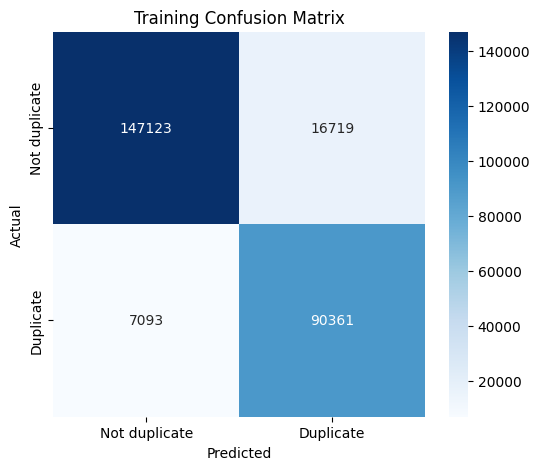


Classification Report:

              precision    recall  f1-score   support

           0     0.9540    0.8980    0.9251    163842
           1     0.8439    0.9272    0.8836     97454

    accuracy                         0.9089    261296
   macro avg     0.8989    0.9126    0.9044    261296
weighted avg     0.9129    0.9089    0.9096    261296



In [36]:
train_best_bert_results = classify_analysis_bert(best_trainer, train_dataset, 'Training')

Validation
Log Loss      : 0.3831
ROC-AUC       : 0.9185
F1-score      : 0.7877
Inference time: 157.1475 s


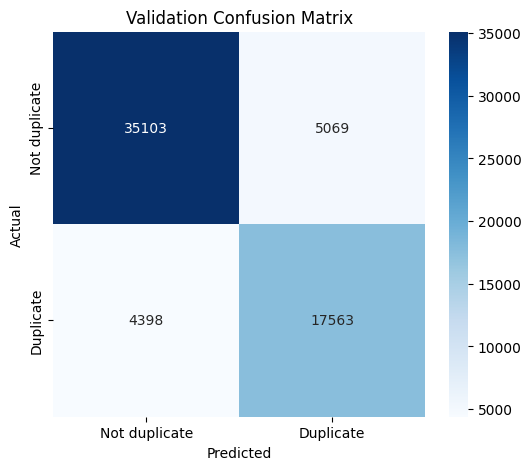


Classification Report:

              precision    recall  f1-score   support

           0     0.8887    0.8738    0.8812     40172
           1     0.7760    0.7997    0.7877     21961

    accuracy                         0.8476     62133
   macro avg     0.8323    0.8368    0.8344     62133
weighted avg     0.8488    0.8476    0.8481     62133



In [25]:
val_best_bert_results = classify_analysis_bert(best_trainer, val_dataset, 'Validation')

# Error analysis

In [39]:
train_bert_errors = error_analysis_bert(train_df, train_bert_results)
train_bert_errors["results"]

Error Analysis

TP : 94346
TN : 158174
FP : 5668
FN : 3108


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,prediction,probability
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,0.210375
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,0.000022
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,0.281402
3,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,train,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,0.998830
4,363829,363830,I got a seat in engineering management in Kett...,I am a petroleum engineer. Got an offer from S...,0,train,I got a seat in engineering management in Kett...,I am a petroleum engineer. Got an offer from S...,0,0.000026
...,...,...,...,...,...,...,...,...,...,...
261291,195424,7058,What changes a female body undergoes after loo...,What might be the reasons why people sometimes...,1,train,What changes a female body undergoes after loo...,What might be the reasons why people sometimes...,1,0.995319
261292,29426,29427,How do I move past my fear and learn options?,How do you move past fear?,0,train,How do I move past my fear and learn options?,How do you move past fear?,0,0.003061
261293,152504,152505,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,train,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,0.003547
261294,54414,54415,What are the tips given to a teacher to satisf...,Can a high school teacher legally force studen...,0,train,What are the tips given to a teacher to satisf...,Can a high school teacher legally force studen...,0,0.000052


In [40]:
val_bert_errors = error_analysis_bert(val_df, val_bert_results)
val_bert_errors["results"]

Error Analysis

TP : 16370
TN : 36457
FP : 3715
FN : 5591


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,prediction,probability
0,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,val,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,0.000019
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,How can I open a PPF account? And what are its...,What is PPF account?,0,0.115386
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",0,0.015107
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,0,0.001438
4,353543,353544,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0,val,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0,0.014794
...,...,...,...,...,...,...,...,...,...,...
62128,87381,87382,What is adaptive expectation?,What is adaptability?,0,val,What is adaptive expectation?,What is adaptability?,0,0.000181
62129,6270,343259,What is the solution to this puzzle?,What is the solution to these puzzles?,0,val,What is the solution to this puzzle?,What is the solution to these puzzles?,0,0.000432
62130,89946,89947,What types of questions are asked in front-end...,What interview questions should I ask a front ...,0,val,What types of questions are asked in front-end...,What interview questions should I ask a front ...,0,0.006015
62131,182893,182894,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,val,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,0.000037


In [41]:
train_best_bert_errors = error_analysis_bert(train_df, train_best_bert_results)
train_best_bert_errors["results"]

Error Analysis

TP : 90361
TN : 147123
FP : 16719
FN : 7093


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,prediction,probability
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,What is practical management and what is strat...,What are the practical aspects of strategic ma...,1,0.786439
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,0.000279
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,Which is the best place to reside in India and...,Which ia the best place to visit in India?,1,0.877436
3,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,train,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,0.984698
4,363829,363830,I got a seat in engineering management in Kett...,I am a petroleum engineer. Got an offer from S...,0,train,I got a seat in engineering management in Kett...,I am a petroleum engineer. Got an offer from S...,0,0.000242
...,...,...,...,...,...,...,...,...,...,...
261291,195424,7058,What changes a female body undergoes after loo...,What might be the reasons why people sometimes...,1,train,What changes a female body undergoes after loo...,What might be the reasons why people sometimes...,1,0.929227
261292,29426,29427,How do I move past my fear and learn options?,How do you move past fear?,0,train,How do I move past my fear and learn options?,How do you move past fear?,1,0.659151
261293,152504,152505,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,train,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,0.074221
261294,54414,54415,What are the tips given to a teacher to satisf...,Can a high school teacher legally force studen...,0,train,What are the tips given to a teacher to satisf...,Can a high school teacher legally force studen...,0,0.000824


In [34]:
val_best_bert_errors = error_analysis_bert(val_df, val_best_bert_results)
val_best_bert_errors["results"]

Error Analysis

TP : 17563
TN : 35103
FP : 5069
FN : 4398


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,prediction,probability
0,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,val,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,0.000256
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,How can I open a PPF account? And what are its...,What is PPF account?,1,0.537288
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",0,0.001462
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,0,0.016901
4,353543,353544,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0,val,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0,0.217407
...,...,...,...,...,...,...,...,...,...,...
62128,87381,87382,What is adaptive expectation?,What is adaptability?,0,val,What is adaptive expectation?,What is adaptability?,0,0.000771
62129,6270,343259,What is the solution to this puzzle?,What is the solution to these puzzles?,0,val,What is the solution to this puzzle?,What is the solution to these puzzles?,0,0.011365
62130,89946,89947,What types of questions are asked in front-end...,What interview questions should I ask a front ...,0,val,What types of questions are asked in front-end...,What interview questions should I ask a front ...,0,0.044687
62131,182893,182894,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,val,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,0.000370


**Observation:**
- Checkpoint 48000 (most training) overfits: train Log Loss ~0.11 vs. val Log Loss ~0.57.
- Checkpoint 14000, selected by validation performance rather than by training the longest, generalizes much better and achieves the highest F1 score in the entire project (~0.79).
- Despite strong quality, inference time (~157s) makes this model impractical for a low-latency production API.

# Next steps

- Try RoBERTa for comparison.
- Consider early stopping tied explicitly to a validation metric to avoid wasting compute on checkpoints past the optimum.